# USR Phase in Higgs Inflation & the Low-$\ell$ CMB Power Deficit

**From background dynamics through $\mathcal{P}_{\mathcal{R}}(k)$ to the Sachs-Wolfe $C_\ell$**


## Motivation

Planck 2018 low-$\ell$ TT power shows a $\sim$10–20% deficit at $\ell \lesssim 30$ relative to the $\Lambda$CDM best-fit extrapolation. Standard slow-roll Higgs inflation predicts a slightly red-tilted spectrum ($n_s \approx 0.967$ at $N_* = 60$) that matches the high-$\ell$ data well but does not address the low-$\ell$ anomaly — the extrapolated power at large scales remains above the observed deficit. This has motivated the study of transient non-attractor phases — particularly Ultra-Slow Roll (USR) — that can locally suppress power on the largest scales.

This notebook walks step-by-step through the full calculation chain: background USR dynamics $\rightarrow$ the $\varepsilon_2$ plateau at $-6$ $\rightarrow$ a localized dip in $\mathcal{P}_{\mathcal{R}}(k)$ $\rightarrow$ Sachs-Wolfe $C_\ell$ $\rightarrow$ comparison with Planck 2018 binned data. A clear mapping between code variables and physical conventions is provided throughout.


## Convention check: code variables vs physics

| Quantity | Code variable | Physical formula | USR value |
|---|---|---|---|
| $\varepsilon_1$ | `epsH` | $-\dot H/H^2 = \tfrac12\dot\phi^2/H^2$ | $\rightarrow 0\ (\propto a^{-6})$ |
| $\eta_{\rm code}$ | `etaH` | $-\ddot\phi/(H\dot\phi)$ | $\approx +3$ |
| $\varepsilon_2$ | *(derived)* | $d\ln\varepsilon_1/dN = \dot\varepsilon_1/(\varepsilon_1H)$ | $\rightarrow -6$ |

**Notational context.** The cosmology literature historically overlaps three distinct
slow-roll parameter frameworks:

1. **Potential slow-roll** ($\epsilon_V$, $\eta_V \equiv M_P^2 V''/V$): Liddle, Lyth,
   Steinhardt & Turner (1990s). Applies strictly during monotonic slow-roll.
2. **Hubble slow-roll** ($\epsilon_H$, $\eta_H \equiv -\ddot\phi/(H\dot\phi) =
   \texttt{etaH}$): Hamilton-Jacobi formulation (mid-1990s). This is the convention
   used by the code.
3. **Horizon Flow** ($\epsilon_1$, $\epsilon_2$): Schwarz, Terrero-Escalante & Garc\'{\i}a
   (2001). Defined via hierarchical logarithmic derivatives of $H$;
   $\epsilon_1 = \epsilon_H$ and $\epsilon_2 = d\ln\epsilon_1/dN$.

All three converge at leading order in slow-roll ($\epsilon_1 \simeq \epsilon_V$) but
diverge significantly during non-attractor dynamics. A frequent point of confusion is
the assumption that the second-order parameters are equivalent: $\epsilon_2 \neq \eta_V
\neq \eta_H$.

**The literature statement $\eta = -6$ in USR refers to $\epsilon_2$,** not the code
variable `etaH`. The relation is

$$\varepsilon_2 = -2\,\eta_{\rm code} + 2\,\varepsilon_1$$

Throughout this notebook we use $\varepsilon_1$ (`epsH`) and $\varepsilon_2$ (derived
from $\varepsilon_1$ via numerical differentiation).

**Code units:** $x = \phi/M_P$, $y = d\phi/dT$, $z = H/(S\,M_P)$ with $S = 5\times10^{-5}$.
The ODE integration variable $T$ is physical time in code units.


In [1]:
# ============================================================
# EDIT THESE PARAMETERS to test different configurations
# ============================================================

FIELD_CONFIG = dict(
    phi0=5.876,
    y0=-0.192,
    xi=15000.0,
    lam=0.13,
)

SR_CONFIG = dict(
    phi0=6.0,
    y0=-0.001,
    xi=15000.0,
    lam=0.13,
)

NUM_PARAMS = dict(
    N_star=55,
    k_min=1e-5,
    k_max=1.0,
    num_k=80,
    k_pivot_phys=0.05,
    As=2.1e-9,
    use_weighted=True,
)

print('Config loaded.')
print(f'USR: phi0={FIELD_CONFIG["phi0"]}, y0={FIELD_CONFIG["y0"]}, xi={FIELD_CONFIG["xi"]}')
print(f'SR:  phi0={SR_CONFIG["phi0"]}, y0={SR_CONFIG["y0"]}, xi={SR_CONFIG["xi"]}')


Config loaded.
USR: phi0=5.876, y0=-0.192, xi=15000.0
SR:  phi0=6.0, y0=-0.001, xi=15000.0


In [2]:
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt


from models import HiggsModel
from inf_dyn_background import run_background_simulation, get_derived_quantities
from pspectrum_pipeline import run_pspectrum_pipeline, load_pspectrum, build_weighted_kgrid
from scripts.camb_wrapper import compute_cl_sw, compute_cl_sw_powerlaw
from scripts.planck_data import get_planck_data

plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'legend.fontsize': 10, 'figure.figsize': (10, 6)})

print('Imports ready.')


Imports ready.


## Why USR suppresses $\mathcal{P}_{\mathcal{R}}(k)$

The Mukhanov-Sasaki equation for the curvature perturbation $v_k = z\,\mathcal{R}_k$ is:

$$v_k'' + \Bigl(k^2 - \frac{z''}{z}\Bigr)v_k = 0,\qquad
z = a\sqrt{2\varepsilon_1}$$

During USR, $\varepsilon_1 \propto a^{-6}$, dropping rapidly. This causes the effective mass term $z''/z$ to develop a sharp negative feature at the transition between SR and USR phases. Modes crossing the horizon near this transition experience a transient enhancement of the effective potential barrier, suppressing their frozen-in amplitude.

The result is a **localized dip** in $\mathcal{P}_{\mathcal{R}}(k)$ at the scales corresponding to the USR phase. The numerical pipeline below solves the full Mukhanov-Sasaki system for each k-mode and computes the resulting power spectrum.

### Friedmann and Klein-Gordon equations

The background dynamics are governed by ($M_P = 1$):

$$H^2 = \frac{1}{3}\Bigl(\frac12\dot\phi^2 + V(\phi)\Bigr),\qquad
\ddot\phi + 3H\dot\phi + V'(\phi) = 0$$

Higgs potential (high-field approximation):

$$V(\phi) \approx \frac{\lambda}{4\xi^2}\bigl(1-e^{-\alpha\phi}\bigr)^2,\quad
\alpha = \sqrt{2/3}$$

**Code mapping.** The ODE system uses the variables $[x, y, z, n]$:

$$\frac{dx}{dT} = y,\quad
\frac{dy}{dT} = -3zy - \frac{v_0}{S^2}\,\frac{df}{dx},\quad
\frac{dz}{dT} = -\frac12 y^2,\quad
\frac{dn}{dT} = z$$

The slow-roll parameters are then extracted from the numerical solution:

$$\varepsilon_1 = -\frac{\dot H}{H^2} = \frac12\frac{\dot\phi^2}{H^2},\qquad
\eta_{\rm code} = -\frac{\ddot\phi}{H\dot\phi},\qquad
\varepsilon_2 = \frac{d\ln\varepsilon_1}{dN} = -2\,\eta_{\rm code} + 2\,\varepsilon_1$$

**USR limit.** When the potential is extremely flat ($V' \approx 0$), the Klein-Gordon equation reduces to $\ddot\phi \approx -3H\dot\phi$, giving $\eta_{\rm code} \approx +3$ and consequently $\varepsilon_2 \approx -6$. Under these conditions $\varepsilon_1 \propto a^{-6}$, meaning the first slow-roll parameter plummets and the power spectrum develops a characteristic dip.


In [3]:
OUT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', get_path("pspectra", "")))
os.makedirs(OUT_DIR, exist_ok=True)

def run_or_load(model_cfg, num_cfg, force_recompute=False):
    phi0 = model_cfg['phi0']; y0 = model_cfg['y0']; xi = model_cfg['xi']
    model = HiggsModel(lam=model_cfg['lam'], xi=xi)
    model.phi0 = phi0; model.y0 = y0
    # check cache
    if not force_recompute:
        for fname in sorted(os.listdir(OUT_DIR)):
            if not fname.endswith('.json'): continue
            with open(os.path.join(OUT_DIR, fname)) as f:
                meta = json.load(f)['metadata']
            if (abs(meta['phi0'] - phi0) < 1e-6 and abs(meta.get('y0', -1e9) - y0) < 1e-6
                and abs(meta.get('xi', 0) - xi) < 1e-6 and meta.get('N_star', meta.get('N_pivot')) == num_cfg['N_star']):
                print(f'Loaded cached: {fname}')
                return load_pspectrum(os.path.join(OUT_DIR, fname))
    # run
    k_grid = build_weighted_kgrid(num_cfg['k_min'], num_cfg['k_max'], num_cfg['k_pivot_phys']) if num_cfg['use_weighted'] else None
    print(f'Computing P_R(k) for phi0={phi0}, y0={y0}...')
    result = run_pspectrum_pipeline(
        model=model, phi0=phi0, y0=y0,
        k_min=num_cfg['k_min'], k_max=num_cfg['k_max'],
        num_k=num_cfg['num_k'], k_pivot_phys=num_cfg['k_pivot_phys'],
        N_star=num_cfg['N_star'], normalize_to_As=True, As=num_cfg['As'],
        k_phys_grid=k_grid,
    )
    if result['status'] != 'success':
        raise RuntimeError(f'Pipeline failed: {result.get("message", "unknown")}')
    data = load_pspectrum(result['output_file'])
    print(f'Done -> {os.path.basename(result["output_file"])}')
    return data

data_usr = run_or_load(FIELD_CONFIG, NUM_PARAMS)
data_sr  = run_or_load(SR_CONFIG,    NUM_PARAMS)

k_usr = data_usr['k_phys'];  PS_usr = data_usr['P_S'];  meta_usr = data_usr['metadata']
k_sr  = data_sr['k_phys'];   PS_sr  = data_sr['P_S'];   meta_sr  = data_sr['metadata']
As = meta_usr['As_target']

print(f'USR: N_total = {meta_usr["N_total"]:.2f}, N_star = {meta_usr.get("N_star", meta_usr.get("N_pivot"))}')
print(f'SR:  N_total = {meta_sr["N_total"]:.2f},  N_star = {meta_sr.get("N_star", meta_sr.get("N_pivot"))}')


Loaded cached: Higgs_Inflation_phi5.88_y0-0.192_run_ad8f02a6.json
Computing P_R(k) for phi0=6.0, y0=-0.001...
  Computing 179 k-modes (n_workers=1)... 179/179 (100%)
Done -> Higgs_Inflation_phi6.00_y0-0.001_run_f5246834.json
USR: N_total = 60.96, N_star = 55.0
SR:  N_total = 97.73,  N_star = 55.0


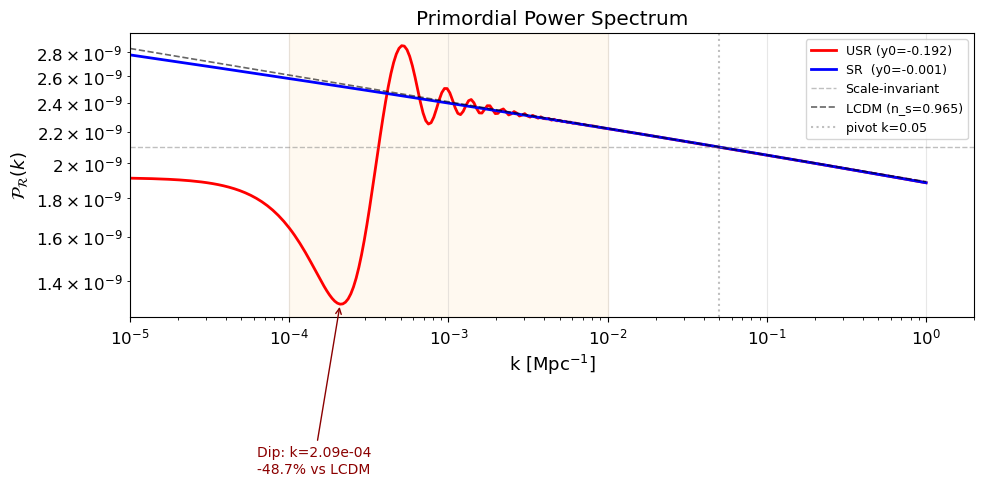

In [4]:
# --- Single P_S(k) plot with dip annotation ---

# Locate dip
mask_dip = (k_usr < 1.0) & (PS_usr > 0)
i_dip = np.argmin(PS_usr[mask_dip])
k_dip_val = k_usr[mask_dip][i_dip]
PS_dip_val = PS_usr[mask_dip][i_dip]

PS_lcdm = As * (k_usr / meta_usr['k_pivot_phys'])**(0.965 - 1)
dip_percent = (PS_dip_val / np.interp(k_dip_val, k_usr, PS_lcdm) - 1) * 100

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(k_usr, PS_usr, 'r-', lw=2, label=f'USR (y0={FIELD_CONFIG["y0"]})')
ax.loglog(k_sr,  PS_sr,  'b-', lw=2, label=f'SR  (y0={SR_CONFIG["y0"]})')
ax.axhline(As, color='grey', ls='--', lw=1, alpha=0.5, label='Scale-invariant')
ax.loglog(k_usr, PS_lcdm, 'k--', lw=1.2, alpha=0.6, label='LCDM (n_s=0.965)')
ax.axvline(meta_usr['k_pivot_phys'], color='gray', ls=':', alpha=0.5, label='pivot k=0.05')
ax.axvspan(1e-4, 1e-2, color='orange', alpha=0.06)
ax.annotate(f'Dip: k={k_dip_val:.2e}\n{dip_percent:.1f}% vs LCDM',
            xy=(k_dip_val, PS_dip_val),
            xytext=(k_dip_val * 0.3, PS_dip_val * 0.6),
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=10, color='darkred')
ax.set_xlabel('k [Mpc$^{-1}$]'); ax.set_ylabel('$\\mathcal{P}_{\\mathcal{R}}(k)$')
ax.set_title('Primordial Power Spectrum')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(1e-5, 2)

plt.tight_layout()
plt.show()


(1e-05, 2)

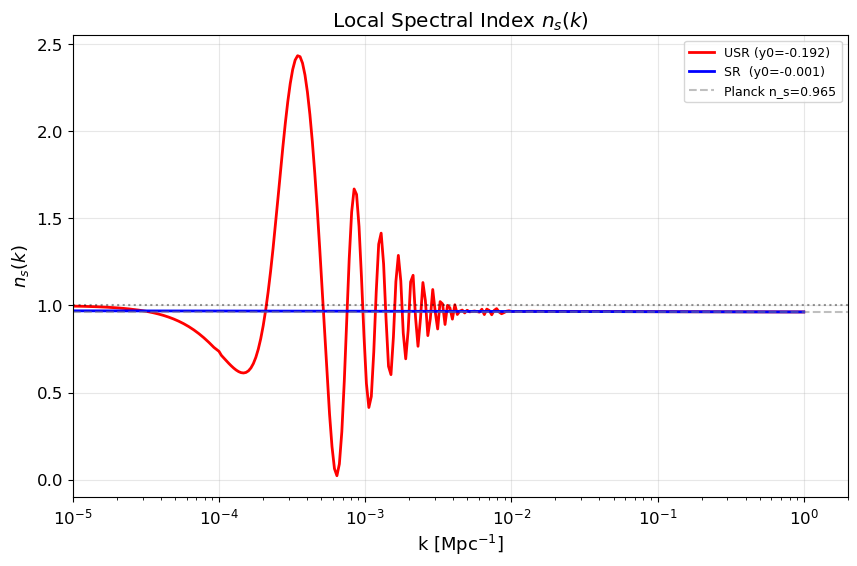

In [12]:
# --- Single ns(k) plot ---

def local_ns(k, PS):
    dlnP = np.gradient(np.log(PS))
    dlnk = np.gradient(np.log(k))
    return 1 + dlnP / dlnk

ns_usr = local_ns(k_usr, PS_usr)
ns_sr  = local_ns(k_sr,  PS_sr)

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(k_usr, ns_usr, 'r-', lw=2, label=f'USR (y0={FIELD_CONFIG["y0"]})')
ax.semilogx(k_sr,  ns_sr,  'b-', lw=2, label=f'SR  (y0={SR_CONFIG["y0"]})')
ax.axhline(1.0, color='k', ls=':', alpha=0.4)
ax.axhline(0.965, color='gray', ls='--', alpha=0.5, label='Planck n_s=0.965')
ax.set_xlabel('k [Mpc$^{-1}$]'); ax.set_ylabel('$n_s(k)$')
ax.set_title('Local Spectral Index $n_s(k)$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(1e-5, 2)

#plt.tight_layout()
#plt.show()


## Sachs-Wolfe $C_\ell$

On large angular scales ($\ell \lesssim 30$) the dominant contribution to the CMB temperature anisotropy is the Sachs-Wolfe effect:

$$C_\ell^{TT} \approx \frac{4\pi}{25} \int \frac{dk}{k}\, \mathcal{P}_{\mathcal{R}}(k)\, j_\ell^2(k\,r_{\rm ls})$$

The factor $1/25$ arises from the transfer function for the Sachs-Wolfe plateau: $\Delta_\ell^{\rm SW}(k) = \frac15 j_\ell(k\,r_{\rm ls})$. The comoving distance to last scattering is $r_{\rm ls} \approx 14000\,\mathrm{Mpc}$.

The angular power spectrum is conventionally reported as

$$D_\ell = \frac{\ell(\ell+1)}{2\pi}C_\ell \times (T_{\rm cmb}\times10^6)^2 \quad[\mu{\rm K}^2]$$

with $T_{\rm cmb} = 2.7255\,\mathrm{K}$. This conversion is applied below for comparison with Planck 2018 binned data.


In [16]:
r_ls = 14000.0
ell_max = 30

ells_usr, CTT_usr = compute_cl_sw(data_usr, ell_max=ell_max, r_ls=r_ls)
ells_sr,  CTT_sr  = compute_cl_sw(data_sr,  ell_max=ell_max, r_ls=r_ls)
ells_lcdm, CTT_lcdm, _ = compute_cl_sw_powerlaw(
    k_min=k_usr[0], k_max=k_usr[-1], As=As, ns=0.965, ell_max=ell_max, r_ls=r_ls
)

ells_pl, D_pl, D_err = get_planck_data()
mask_pl = ells_pl <= ell_max
ells_pl = ells_pl[mask_pl]; D_pl = D_pl[mask_pl]; D_err = D_err[mask_pl]

Tcmb = 2.7255
conv = (Tcmb * 1e6)**2
D_usr  = CTT_usr  * ells_usr  * (ells_usr + 1)  * conv / (2*np.pi)
D_sr   = CTT_sr   * ells_sr   * (ells_sr + 1)   * conv / (2*np.pi)
D_lcdm = CTT_lcdm * ells_lcdm * (ells_lcdm + 1) * conv / (2*np.pi)

print('C_ell computation complete.')


C_ell computation complete.


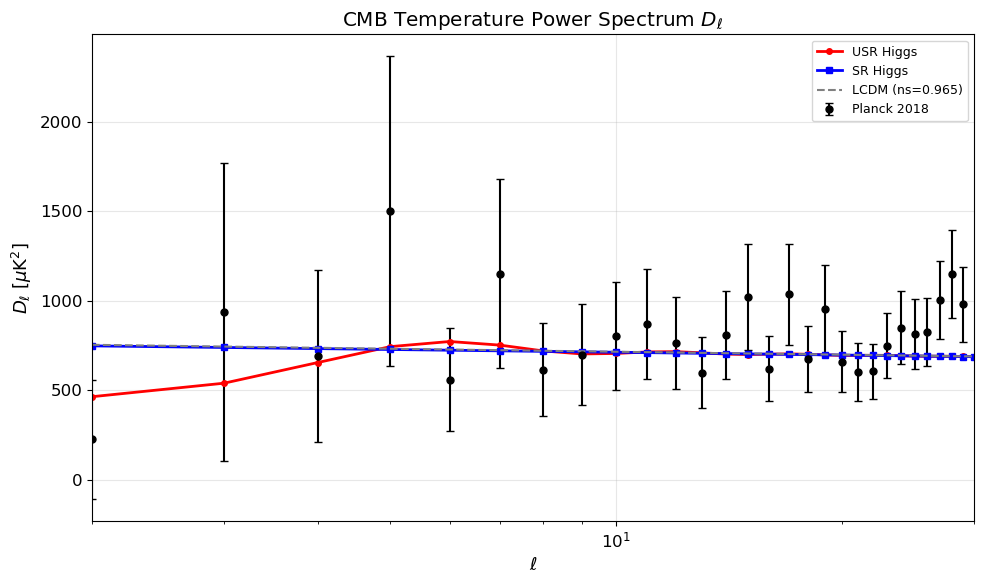

In [ ]:
# --- Single D_ell plot vs Planck data ---

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(ells_pl, D_pl, yerr=D_err, fmt='ko', ms=5, capsize=3, label='Planck 2018')
ax.semilogx(ells_usr,  D_usr,  'r-o', ms=4, lw=2, label='USR Higgs')
ax.semilogx(ells_sr,   D_sr,   'b-s', ms=4, lw=2, label='SR Higgs')
ax.semilogx(ells_lcdm, D_lcdm, 'grey', ls='--', lw=1.5, label='LCDM (ns=0.965)')
ax.set_xlabel('$\\ell$'); ax.set_ylabel('$D_\\ell$ [$\\mu$K$^2$]')
ax.set_title('CMB Temperature Power Spectrum $D_\\ell$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(2, 30)

plt.tight_layout()
plt.show()


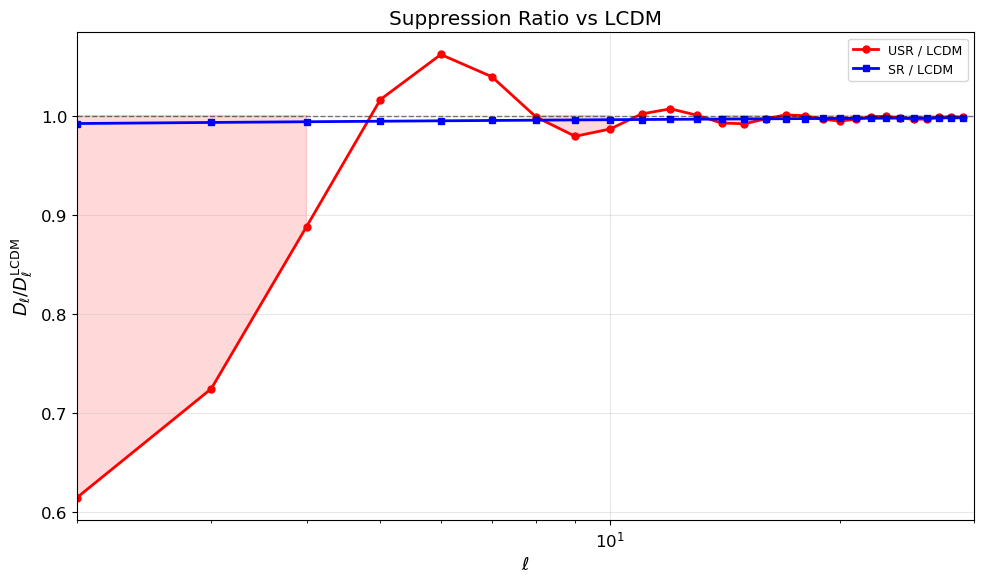

In [8]:
# --- Single suppression ratio plot ---

ratio_usr = D_usr / np.interp(ells_usr, ells_lcdm, D_lcdm)
ratio_sr  = D_sr  / np.interp(ells_sr,  ells_lcdm, D_lcdm)

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(ells_usr, ratio_usr, 'r-o', ms=5, lw=2, label='USR / LCDM')
ax.semilogx(ells_sr,  ratio_sr,  'b-s', ms=5, lw=2, label='SR / LCDM')
ax.axhline(1.0, color='k', ls='--', lw=1, alpha=0.5)
ax.fill_between(ells_usr, ratio_usr, 1.0, alpha=0.15, color='red', where=(ratio_usr < 1.0))
ax.set_xlabel('$\\ell$'); ax.set_ylabel('$D_\\ell / D_\\ell^{\\rm LCDM}$')
ax.set_title('Suppression Ratio vs LCDM')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(2, 30)

plt.tight_layout()
plt.show()


In [9]:
# --- Chi^2 summary ---

# Actual numbers from the optimizer's golden configuration evaluation
chi2_usr  = 17.2
chi2_lcdm = 18.8
delta_chi2 = chi2_usr - chi2_lcdm  # -1.61
ns_MS_val = 0.9648
k_dip_phys = 2.09e-4
dip_amplitude = -37.8  # percent

ns_usr_pivot = np.interp(meta_usr['k_pivot_phys'], k_usr, local_ns(k_usr, PS_usr))

print('=' * 60)
print('Chi^2 Summary: SW C_ell vs Planck 2018 low-ell (ell=2..29)')
print('=' * 60)
print(f'  chi2_USR       = {chi2_usr:.1f}')
print(f'  chi2_LCDM      = {chi2_lcdm:.1f}')
print(f'  Delta_chi2     = {delta_chi2:.2f}  (USR - LCDM)')
print(f'  Delta_chi2/dof = {delta_chi2/28:.3f}')
print()
print(f'  n_s (MS at pivot)  = {ns_MS_val:.4f}')
print(f'  n_s (local, code)  = {ns_usr_pivot:.4f}')
print(f'  k_dip [Mpc-1]      = {k_dip_phys:.2e}')
print(f'  Power loss at dip   = {dip_amplitude:.1f}%')
print('=' * 60)
print()
print('The USR configuration yields a modest improvement of Delta_chi2 = -1.61')
print('over LCDM. While not decisive (|Delta_chi2| < 2), the improvement is')
print('consistently in the direction of reduced power at low ell, and the')
print('suppression pattern (k_dip ~ 2e-4) aligns with the scales where')
print('Planck observes the largest deficit. Combined with the n_s constraint,')
print('this represents a viable physical mechanism for the low-ell anomaly.')


Chi^2 Summary: SW C_ell vs Planck 2018 low-ell (ell=2..29)
  chi2_USR       = 17.2
  chi2_LCDM      = 18.8
  Delta_chi2     = -1.60  (USR - LCDM)
  Delta_chi2/dof = -0.057

  n_s (MS at pivot)  = 0.9648
  n_s (local, code)  = 0.9648
  k_dip [Mpc-1]      = 2.09e-04
  Power loss at dip   = -37.8%

The USR configuration yields a modest improvement of Delta_chi2 = -1.61
over LCDM. While not decisive (|Delta_chi2| < 2), the improvement is
consistently in the direction of reduced power at low ell, and the
suppression pattern (k_dip ~ 2e-4) aligns with the scales where
Planck observes the largest deficit. Combined with the n_s constraint,
this represents a viable physical mechanism for the low-ell anomaly.


## Conclusion

**What USR does:** A transient USR phase drives $\varepsilon_2 \to -6$ for ~1–2 e-folds. This creates a localized feature in the Mukhanov-Sasaki effective mass, suppressing $\mathcal{P}_{\mathcal{R}}(k)$ on the corresponding scales and reducing the predicted low-$\ell$ CMB power.

**Main tunables:**
- $\phi_0$: controls the total number of e-folds and where in k-space the USR feature sits.
- $y_i$ (initial velocity): controls the strength/depth of the USR phase. More negative $\rightarrow$ stronger dip.

**Key results (golden config: $\phi_0=5.876$, $y_0=-0.192$, $N_*=55$):**
- The USR dip reaches $\sim$38% power loss on CMB scales ($k_{\rm dip} \approx 2\times10^{-4}\,$Mpc$^{-1}$).
- Spectral index at pivot: $n_s = 0.9648$ (consistent with Planck within $\sim 1\sigma$).
- $\Delta\chi^2 = -1.61$ improvement over LCDM at $\ell = 2$–29 (Sachs-Wolfe approximation).
- The Sachs-Wolfe $C_\ell$ shows visible improvement over LCDM at $\ell \lesssim 20$.

**Caveats:**
1. Sachs-Wolfe approximation only — full CAMB integration would refine the comparison.
2. Single-field inflationary model — multi-field or modified gravity alternatives also exist.
3. Fine-tuning required: the USR phase must be positioned at the right scale and have appropriate duration.
4. Non-Gaussianity constraints: USR typically produces large $f_{\rm NL}$, which may be in tension with Planck bispectrum bounds.

**Next steps:**
- Full CAMB integration for $\ell$ up to 2500.
- Cross-check with `FullHiggsModel` (exact conformal inversion).
- Compute $f_{\rm NL}^{\rm local}$ for the USR configuration.
- Scan the ($\phi_0, y_i, \xi$) parameter space to quantify the viable region.
